In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from pyswarm import pso  # Install using `pip install pyswarm`
from multiprocessing import Pool

# Check GPU availability
print("Num GPUs Available:", len(tf.config.experimental.list_physical_devices('GPU')))

# Load dataset
file_path = "C:/Users/Ashita Singh/Documents/AQI Project/AirQuality_Cleaned.csv"
df = pd.read_csv(file_path)

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Create cyclical features
def create_cyclical_features(df, column, max_val):
    df[column + '_sin'] = np.sin(2 * np.pi * df[column] / max_val)
    df[column + '_cos'] = np.cos(2 * np.pi * df[column] / max_val)
    return df

df['day_of_year'] = df.index.dayofyear
df = create_cyclical_features(df, 'day_of_year', 365)
df.drop(columns=['day_of_year'], inplace=True)

# Select features
features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene',
            'day_of_year_sin', 'day_of_year_cos']
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])
df['AQI'] = scaler.fit_transform(df[['AQI']])

# Create sequences for LSTM
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(df[features].values, df['AQI'].values, seq_length)

# Split dataset
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Use only 10% of training data for PSO
sample_size = int(0.1 * len(X_train))
X_sample, y_sample = X_train[:sample_size], y_train[:sample_size]

# Define PSO objective function
def train_lstm_pso(params):
    lstm_units = int(params[0])
    dropout_rate = params[1]
    batch_size = int(params[2])
    learning_rate = params[3]
    
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=(seq_length, len(features))),
        Dropout(dropout_rate),
        LSTM(lstm_units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    
    # Train with only 1 epoch and 10% of training data
    model.fit(X_sample, y_sample, epochs=1, batch_size=batch_size, validation_data=(X_test[:sample_size], y_test[:sample_size]), verbose=0)
    
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss  # Minimize validation loss

# Define search space with optimized bounds
lb = [10, 0.1, 8, 0.0001]  # Lower bounds (LSTM units, dropout, batch size, learning rate)
ub = [100, 0.5, 32, 0.01]  # Reduced max LSTM units to 100

# Run PSO with multiprocessing (Parallel execution)
if __name__ == "__main__":
    with Pool(processes=4):  # Use 4 parallel processes
        best_params, _ = pso(train_lstm_pso, lb, ub, swarmsize=5, maxiter=3)
    
    print("Optimized Parameters:", best_params)

    # Train final model with best parameters
    best_lstm_units, best_dropout, best_batch_size, best_lr = int(best_params[0]), best_params[1], int(best_params[2]), best_params[3]

    final_model = Sequential([
        LSTM(best_lstm_units, return_sequences=True, input_shape=(seq_length, len(features))),
        Dropout(best_dropout),
        LSTM(best_lstm_units, return_sequences=False),
        Dropout(best_dropout),
        Dense(25, activation='relu'),
        Dense(1)
    ])

    final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='mse')

    # Full training with optimized parameters
    final_model.fit(X_train, y_train, epochs=20, batch_size=best_batch_size, validation_data=(X_test, y_test))

    # Save the final model
    final_model.save("/mnt/data/lstm_air_quality_pso.h5")
    print("PSO-Optimized LSTM Model Training Complete!")



Num GPUs Available: 0
Stopping search: maximum iterations reached --> 3
Optimized Parameters: [5.84521201e+01 4.41171695e-01 3.20000000e+01 1.04506630e-03]
Epoch 1/20
738/738 [==============================] - 14s 13ms/step - loss: 0.0023 - val_loss: 8.8474e-04
Epoch 2/20
738/738 [==============================] - 9s 12ms/step - loss: 0.0019 - val_loss: 6.6509e-04
Epoch 3/20
738/738 [==============================] - 9s 12ms/step - loss: 0.0017 - val_loss: 6.4888e-04
Epoch 4/20
738/738 [==============================] - 9s 12ms/step - loss: 0.0015 - val_loss: 5.4729e-04
Epoch 5/20
738/738 [==============================] - 8s 11ms/step - loss: 0.0013 - val_loss: 4.3648e-04
Epoch 6/20
738/738 [==============================] - 10s 13ms/step - loss: 0.0013 - val_loss: 4.4870e-04
Epoch 7/20
738/738 [==============================] - 9s 12ms/step - loss: 0.0012 - val_loss: 3.9785e-04
Epoch 8/20
738/738 [==============================] - 9s 12ms/step - loss: 0.0012 - val_loss: 4.2457e-04
Ep

C:\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


185/185 [==============================] - 2s 5ms/step
Mean Squared Error (MSE): 1509.97
Root Mean Squared Error (RMSE): 38.86
Mean Absolute Error (MAE): 25.93
R-squared (R²): 0.84


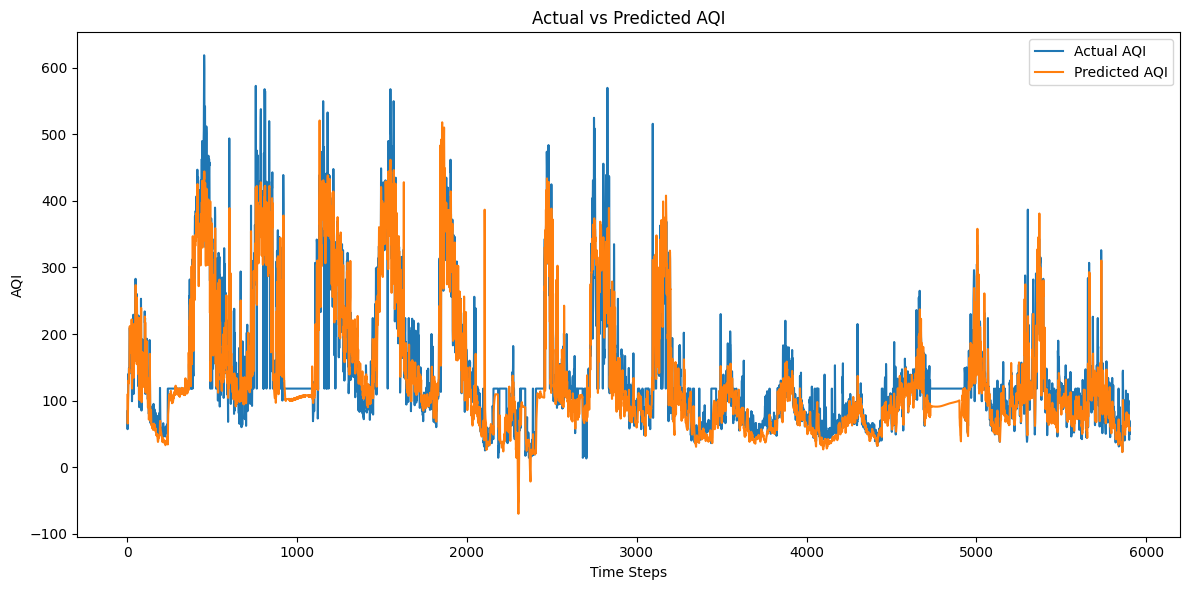

In [2]:
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    # Predict AQI values
    y_pred = final_model.predict(X_test)

    # Inverse transform AQI to get actual scale (since AQI was normalized)
    y_test_actual = scaler.inverse_transform(np.concatenate([np.zeros((len(y_test), len(features))), y_test.reshape(-1,1)], axis=1))[:,-1]
    y_pred_actual = scaler.inverse_transform(np.concatenate([np.zeros((len(y_pred), len(features))), y_pred], axis=1))[:,-1]

    # Evaluation metrics
    mse = mean_squared_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, y_pred_actual)
    r2 = r2_score(y_test_actual, y_pred_actual)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R²): {r2:.2f}")

    # Plotting
    plt.figure(figsize=(12,6))
    plt.plot(y_test_actual, label='Actual AQI')
    plt.plot(y_pred_actual, label='Predicted AQI')
    plt.title('Actual vs Predicted AQI')
    plt.xlabel('Time Steps')
    plt.ylabel('AQI')
    plt.legend()
    plt.tight_layout()
    plt.show()
